# Comprehensive Exploratory Data Analysis (EDA) Pipeline — Bank Dataset
Objective: This notebook provides a rigorous, question-driven framework for "First Look" analysis, data quality assessment, univariate exploration, multivariate relationship discovery, and a final summary report.

Why do we do EDA?
EDA is critical for:

Detection of mistakes (e.g., data entry errors, outliers, impossible values).
Checking of assumptions (e.g., Is the data Normal? Is variance equal?).
Preliminary selection of models (determining which algorithms fit the data shape).
Determining relationships among explanatory and outcome variables.


##  Setup: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


# Section 0: Ridge Regression Baseline (Pre-EDA Model)
Purpose: Before diving into EDA, we establish a baseline predictive model for loan_amount.
This gives us a benchmark score to compare against after EDA-informed feature engineering.

Why Ridge before EDA?

Establishes a numeric performance floor (MAE, RMSE, R²) with raw, minimally processed features.
Any improvements after EDA-driven cleaning confirm the value of the analysis.
Uses a Pipeline to safely handle imputation + encoding, so raw/messy data won't crash training.
Pipeline Architecture:

Raw Features
    ├── Numeric  → SimpleImputer(mean)   → Ridge(α=1.0)
    └── Categorical → SimpleImputer(constant='missing') → OneHotEncoder
Target: loan_amount (raw USD, regression task)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

# Load dataset
df_raw = pd.read_excel("/content/dataclean bank.xlsx") # Changed to pd.read_excel
print("Loaded:", "/content/dataclean bank.xlsx") # Corrected the path in print statement
print("Shape:", df_raw.shape)

# Check if 'loans.loan_amount' exists
if "loan_amount" not in df_raw.columns:
    raise KeyError("The column 'loan_amount' was not found in the DataFrame. Please check the dataset columns.")

# Target column (original loan amount, without log)
target_col = "loan_amount"

# Drop rows where the target column is NaN
df_raw.dropna(subset=[target_col], inplace=True)

# Features (exclude target)
feature_cols = [c for c in df_raw.columns if c != target_col]

X = df_raw[feature_cols].copy()
y = df_raw[target_col].copy()

# Identify numeric and categorical features
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Ridge regression baseline
model = Ridge(alpha=1.0, random_state=42)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline
pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
pipe.fit(X_train, y_train)

# Predictions
pred = pipe.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)
r2   = r2_score(y_test, pred)

print(f"Baseline Ridge on Loan Amount | RMSE=${rmse:,.0f} | MAE=${mae:,.0f} | R2={r2:.3f}")

Loaded: /content/dataclean bank.xlsx
Shape: (38838, 31)
Baseline Ridge on Loan Amount | RMSE=$58,243 | MAE=$40,997 | R2=0.626


---
#  Section A: Dataset Overview + Types


## Q1 — Dataset Overview: What do we have?
**Goal:** Get a first look at the dataset's size, structure, and sample rows.

**Deliverables:**
- `df.shape` → number of rows and columns
- `df.head()` → 5 sample rows
- `df.columns` → all column names

**Why it matters:** Knowing the "shape" (n rows × p columns) immediately tells us whether we are working with a small, medium, or large dataset, and how many features we need to understand.


In [ ]:
def load_and_inspect(filepath='data.csv', file_type='csv'):
    """
    Loads dataset and performs initial structural inspection.
    Reports shape, info, and displays first 5 rows.
    """
    try:
        if file_type == 'csv':
            df = pd.read_csv(filepath)
        elif file_type == 'excel':
            df = pd.read_excel(filepath)

        print(f"Data Loaded: {df.shape[0]} Rows, {df.shape[1]} Columns")
        print(df.info())

        display(df.head())

        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return None


In [ ]:
# Load the dataset
df = load_and_inspect('/content/dataclean bank.xlsx', 'excel')


Data Loaded: 38838 Rows, 31 Columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38838 entries, 0 to 38837
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   account_id             38838 non-null  object 
 1   customer_id            38838 non-null  object 
 2   card_id                38838 non-null  object 
 3   Full_Name_customer     38838 non-null  object 
 4   customers.email        38838 non-null  object 
 5   account_type           38838 non-null  object 
 6   balance_usd            38838 non-null  float64
 7   open_date              38838 non-null  object 
 8   created_at             38838 non-null  object 
 9   expiration_date        33504 non-null  object 
 10  card_type              38838 non-null  object 
 11  city                   38838 non-null  object 
 12  credit_score           38838 non-null  int64  
 13  merchant_id            38838 non-null  object 
 14  merchant_name     

,account_id,customer_id,card_id,Full_Name_customer,customers.email,account_type,balance_usd,open_date,created_at,expiration_date,card_type,city,credit_score,merchant_id,merchant_name,merchants.city,loan_id,loan_amount,interest_rate,start_date,employee_id,employees_full_name,employees_role,employees_user_name,branch_id,Account_Age_Days,Account_Age_Years,loan_status,balance_category,credit_category,loan_to_balance_ratio
0,ACC32AXBRYBVYAR,CUS1PVOPNQ5NOIN,CRD9DMMMTJDQT3V,Emily Patrick,brian26@example.org,Checking,64701.07,2021-05-25,2025-05-27,2032-02-07,Debit,New Amandaberg,654,NO_MERCHANT,No Merchant,No Merchant,LONDFCZEB4WWDMM,15931.56,10.29,2019-10-27,EMP026,Owen Lewis,Manager,olewis81,BRN0UD4BY1DU35Z,1749,4.79,Has Loan,Very High,Fair,0.246233
1,ACCEB8UCOHFXSVQ,CUSHOLL6ZT274K3,CRDFYF0S21APP3U,Susan Bartlett,david13@example.org,Savings,24973.01,2022-09-05,2022-08-27,2029-11-21,Debit,North Lisa,504,MERGDDWPZNUDLC2,Howard-Huff,North Lisa,LONBV3X0H0XGWDM,83787.68,10.36,2019-09-01,EMP001,Sebastian Roberts,Teller,sroberts93,BRNJITQ446NVY1P,1281,3.51,Has Loan,High,Poor,3.355129
2,ACC6AFXSS2OZD5I,CUS4KVHY58PGUXF,CRD2DNTLOV1SEZU,Katelyn Wilkerson,johnnyscott@example.com,Checking,23170.11,2023-04-06,2022-08-17,2031-12-26,Credit,Bethfort,794,NO_MERCHANT,No Merchant,No Merchant,LON8MO4Z8F2MY71,50695.04,7.37,2019-04-25,UNKNOWN,Unknown,Unknown,unknown,UNKNOWN,1068,2.92,Has Loan,High,Very Good,2.187950
3,ACCFXWSO7DM8H8N,CUS7BPAAKLYYY42,CRDW198QOTSQVJO,Brenda Martin,kristymartin@example.net,Checking,21048.22,2024-08-20,2025-05-30,2032-03-13,Credit,Port Michael,533,MER3N0KSR61S7TE,"Gilbert, Watson and Collins",Port Michael,LONHDREEA5JR90K,196049.13,8.10,2024-08-02,UNKNOWN,Unknown,Unknown,unknown,UNKNOWN,566,1.55,Has Loan,High,Poor,9.314285
4,ACC8B80LZXIPH4X,CUSIG7R2FMFP5MD,CRDVFGMQXY4YW5U,Melanie Hamilton,alexismurray@example.com,Business,86025.22,2021-04-27,2019-04-24,2027-11-11,Credit,West Bradley,437,MERU9JCGLS9MNLI,"Williams, Moore and Campbell",West Bradley,NO_LOAN,0.00,0.00,NaN,UNKNOWN,Unknown,Unknown,unknown,UNKNOWN,1777,4.87,No Loan,Very High,Poor,0.000000


In [ ]:
# Q1 — Shape, sample rows, and column names
print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== All Column Names ===")
print(list(df.columns))

print("\n=== 5 Sample Rows ===")
display(df.head())


=== Dataset Shape ===
Rows: 38838, Columns: 31

=== All Column Names ===
['account_id', 'customer_id', 'card_id', 'Full_Name_customer', 'customers.email', 'account_type', 'balance_usd', 'open_date', 'created_at', 'expiration_date', 'card_type', 'city', 'credit_score', 'merchant_id', 'merchant_name', 'merchants.city', 'loan_id', 'loan_amount', 'interest_rate', 'start_date', 'employee_id', 'employees_full_name', 'employees_role', 'employees_user_name', 'branch_id', 'Account_Age_Days', 'Account_Age_Years', 'loan_status', 'balance_category', 'credit_category', 'loan_to_balance_ratio']

=== 5 Sample Rows ===


,account_id,customer_id,card_id,Full_Name_customer,customers.email,account_type,balance_usd,open_date,created_at,expiration_date,card_type,city,credit_score,merchant_id,merchant_name,merchants.city,loan_id,loan_amount,interest_rate,start_date,employee_id,employees_full_name,employees_role,employees_user_name,branch_id,Account_Age_Days,Account_Age_Years,loan_status,balance_category,credit_category,loan_to_balance_ratio
0,ACC32AXBRYBVYAR,CUS1PVOPNQ5NOIN,CRD9DMMMTJDQT3V,Emily Patrick,brian26@example.org,Checking,64701.07,2021-05-25,2025-05-27,2032-02-07,Debit,New Amandaberg,654,NO_MERCHANT,No Merchant,No Merchant,LONDFCZEB4WWDMM,15931.56,10.29,2019-10-27,EMP026,Owen Lewis,Manager,olewis81,BRN0UD4BY1DU35Z,1749,4.79,Has Loan,Very High,Fair,0.246233
1,ACCEB8UCOHFXSVQ,CUSHOLL6ZT274K3,CRDFYF0S21APP3U,Susan Bartlett,david13@example.org,Savings,24973.01,2022-09-05,2022-08-27,2029-11-21,Debit,North Lisa,504,MERGDDWPZNUDLC2,Howard-Huff,North Lisa,LONBV3X0H0XGWDM,83787.68,10.36,2019-09-01,EMP001,Sebastian Roberts,Teller,sroberts93,BRNJITQ446NVY1P,1281,3.51,Has Loan,High,Poor,3.355129
2,ACC6AFXSS2OZD5I,CUS4KVHY58PGUXF,CRD2DNTLOV1SEZU,Katelyn Wilkerson,johnnyscott@example.com,Checking,23170.11,2023-04-06,2022-08-17,2031-12-26,Credit,Bethfort,794,NO_MERCHANT,No Merchant,No Merchant,LON8MO4Z8F2MY71,50695.04,7.37,2019-04-25,UNKNOWN,Unknown,Unknown,unknown,UNKNOWN,1068,2.92,Has Loan,High,Very Good,2.187950
3,ACCFXWSO7DM8H8N,CUS7BPAAKLYYY42,CRDW198QOTSQVJO,Brenda Martin,kristymartin@example.net,Checking,21048.22,2024-08-20,2025-05-30,2032-03-13,Credit,Port Michael,533,MER3N0KSR61S7TE,"Gilbert, Watson and Collins",Port Michael,LONHDREEA5JR90K,196049.13,8.10,2024-08-02,UNKNOWN,Unknown,Unknown,unknown,UNKNOWN,566,1.55,Has Loan,High,Poor,9.314285
4,ACC8B80LZXIPH4X,CUSIG7R2FMFP5MD,CRDVFGMQXY4YW5U,Melanie Hamilton,alexismurray@example.com,Business,86025.22,2021-04-27,2019-04-24,2027-11-11,Credit,West Bradley,437,MERU9JCGLS9MNLI,"Williams, Moore and Campbell",West Bradley,NO_LOAN,0.00,0.00,NaN,UNKNOWN,Unknown,Unknown,unknown,UNKNOWN,1777,4.87,No Loan,Very High,Poor,0.000000


## Q2 — Column Understanding: What does each column represent?
**Goal:** Write one line per column describing its meaning, expected data type, and basic rule.

**Deliverable:** Bullet list — one entry per column.

**Why it matters:** Without understanding what each column means in business terms, you cannot make correct decisions about cleaning, transformations, or feature engineering.

###  Column Dictionary

| Column | Meaning | Expected Type | Basic Rule |
|---|---|---|---|
| `account_id` | Unique identifier for each bank account | Categorical (ID) | Must be unique, no nulls |
| `customer_id` | Unique identifier for each customer | Categorical (ID) | Should be unique, no nulls |
| `card_id` | Unique identifier for each credit/debit card | Categorical (ID) | Should be unique, no nulls |
| `Full_Name_customer` | Customer's full name | Categorical (text) | Non-null, free text |
| `customers.email` | Customer's email address | Categorical (text) | Must contain '@', non-null |
| `account_type` | Type of account (Checking / Savings / Business) | Categorical | Limited values (3 categories) |
| `balance_usd` | Current account balance in USD | Numeric (float) | Non-negative (can be 0) |
| `open_date` | Date when the account was opened | Date (string → datetime) | Must be a valid past date |
| `created_at` | Timestamp when the record was created | Date (string → datetime) | Should be ≥ open_date |
| `expiration_date` | Card expiration date | Date (string → datetime) | Should be a future date; nullable (13.5% missing) |
| `card_type` | Type of credit/debit card | Categorical | Limited values |
| `city` | Customer's city of residence | Categorical | Free text; may need standardization |
| `credit_score` | Customer credit score (numeric) | Numeric (int) | Typical range: 300–850 |
| `merchant_id` | Unique identifier for merchant | Categorical (ID) | Non-null |
| `merchant_name` | Name of the merchant | Categorical (text) | Non-null, free text |
| `merchants.city` | Merchant's city | Categorical | Free text |
| `loan_id` | Unique identifier for the loan | Categorical (ID) | Non-null; may be 'no_loan' placeholder |
| `loan_amount` | Loan amount in USD | Numeric (float) | Non-negative; 0 if no loan |
| `interest_rate` | Annual interest rate on loan | Numeric (float) | 0–100%; 0 if no loan |
| `start_date` | Loan start date | Date (string → datetime) | Valid date; nullable (~55% missing = no-loan rows) |
| `employee_id` | ID of bank employee managing account | Categorical (ID) | Non-null; may be 'UNKNOWN' |
| `employees_full_name` | Full name of the managing employee | Categorical (text) | May be 'Unknown' |
| `employees_role` | Role of the employee (Teller, Manager, etc.) | Categorical | Limited values; may be 'Unknown' |
| `employees_user_name` | System username of the employee | Categorical (text) | May be 'unknown' (~98.7%) |
| `branch_id` | ID of the bank branch | Categorical (ID) | May be 'UNKNOWN' |
| `Account_Age_Days` | Number of days since account was opened | Numeric (int) | Non-negative, derived from open_date |
| `Account_Age_Years` | Account age in years (float) | Numeric (float) | Non-negative, derived feature |
| `loan_status` | Whether the customer has a loan or not | Categorical (binary) | Values: 'Has Loan', 'No Loan' |
| `balance_category` | Categorized balance tier | Categorical (ordinal) | Derived from balance_usd |
| `credit_category` | Categorized credit score tier | Categorical (ordinal) | Derived from credit_score |
| `loan_to_balance_ratio` | Ratio of loan amount to account balance | Numeric (float) | Non-negative; 0 if no loan |


## Q3 — Data Types Check: Are the types correct?
**Goal:** Check `df.dtypes`, identify columns stored in the wrong type, and propose fixes.

**Deliverable:** List of "type problems" + proposed fix.

**Why it matters:** Pandas cannot perform date arithmetic on string columns, and aggregations on object-encoded numbers will silently fail or produce wrong results.

###  Known Type Problems (identified from `df.info()`):

| Column | Current Type | Expected Type | Fix |
|---|---|---|---|
| `open_date` | object (string) | datetime | `pd.to_datetime()` |
| `created_at` | object (string) | datetime | `pd.to_datetime()` |
| `expiration_date` | object (string) | datetime | `pd.to_datetime(errors='coerce')` |
| `start_date` | object (string) | datetime | `pd.to_datetime(errors='coerce')` |


In [ ]:
# Q3 — Show current dtypes
print("=== Current Data Types ===")
print(df.dtypes)

# Identify object columns that should be dates
date_cols = ['open_date', 'created_at', 'expiration_date', 'start_date']
print("\n=== Type Problems — Date Columns Stored as Strings ===")
for col in date_cols:
    print(f"  {col}: {df[col].dtype} → should be datetime")

# Proposed fix: convert to datetime
print("\n=== Applying Fixes ===")
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    print(f"   {col} converted to {df[col].dtype}")


=== Current Data Types ===
account_id                object
customer_id               object
card_id                   object
Full_Name_customer        object
customers.email           object
account_type              object
balance_usd              float64
open_date                 object
created_at                object
expiration_date           object
card_type                 object
city                      object
credit_score               int64
merchant_id               object
merchant_name             object
merchants.city            object
loan_id                   object
loan_amount              float64
interest_rate            float64
start_date                object
employee_id               object
employees_full_name       object
employees_role            object
employees_user_name       object
branch_id                 object
Account_Age_Days           int64
Account_Age_Years        float64
loan_status               object
balance_category          object
credit_category 

##  Working Copy — preserve the loaded dataframe

In [ ]:
# Create a working copy to avoid reloading the file
df2 = df.copy()

# Display all columns when printing dataframes
pd.set_option('display.max_columns', None)
display(df2.head())


,account_id,customer_id,card_id,Full_Name_customer,customers.email,account_type,balance_usd,open_date,created_at,expiration_date,card_type,city,credit_score,merchant_id,merchant_name,merchants.city,loan_id,loan_amount,interest_rate,start_date,employee_id,employees_full_name,employees_role,employees_user_name,branch_id,Account_Age_Days,Account_Age_Years,loan_status,balance_category,credit_category,loan_to_balance_ratio
0,ACC32AXBRYBVYAR,CUS1PVOPNQ5NOIN,CRD9DMMMTJDQT3V,Emily Patrick,brian26@example.org,Checking,64701.07,2021-05-25,2025-05-27,2032-02-07,Debit,New Amandaberg,654,NO_MERCHANT,No Merchant,No Merchant,LONDFCZEB4WWDMM,15931.56,10.29,2019-10-27,EMP026,Owen Lewis,Manager,olewis81,BRN0UD4BY1DU35Z,1749,4.79,Has Loan,Very High,Fair,0.246233
1,ACCEB8UCOHFXSVQ,CUSHOLL6ZT274K3,CRDFYF0S21APP3U,Susan Bartlett,david13@example.org,Savings,24973.01,2022-09-05,2022-08-27,2029-11-21,Debit,North Lisa,504,MERGDDWPZNUDLC2,Howard-Huff,North Lisa,LONBV3X0H0XGWDM,83787.68,10.36,2019-09-01,EMP001,Sebastian Roberts,Teller,sroberts93,BRNJITQ446NVY1P,1281,3.51,Has Loan,High,Poor,3.355129
2,ACC6AFXSS2OZD5I,CUS4KVHY58PGUXF,CRD2DNTLOV1SEZU,Katelyn Wilkerson,johnnyscott@example.com,Checking,23170.11,2023-04-06,2022-08-17,2031-12-26,Credit,Bethfort,794,NO_MERCHANT,No Merchant,No Merchant,LON8MO4Z8F2MY71,50695.04,7.37,2019-04-25,UNKNOWN,Unknown,Unknown,unknown,UNKNOWN,1068,2.92,Has Loan,High,Very Good,2.187950
3,ACCFXWSO7DM8H8N,CUS7BPAAKLYYY42,CRDW198QOTSQVJO,Brenda Martin,kristymartin@example.net,Checking,21048.22,2024-08-20,2025-05-30,2032-03-13,Credit,Port Michael,533,MER3N0KSR61S7TE,"Gilbert, Watson and Collins",Port Michael,LONHDREEA5JR90K,196049.13,8.10,2024-08-02,UNKNOWN,Unknown,Unknown,unknown,UNKNOWN,566,1.55,Has Loan,High,Poor,9.314285
4,ACC8B80LZXIPH4X,CUSIG7R2FMFP5MD,CRDVFGMQXY4YW5U,Melanie Hamilton,alexismurray@example.com,Business,86025.22,2021-04-27,2019-04-24,2027-11-11,Credit,West Bradley,437,MERU9JCGLS9MNLI,"Williams, Moore and Campbell",West Bradley,NO_LOAN,0.00,0.00,NaT,UNKNOWN,Unknown,Unknown,unknown,UNKNOWN,1777,4.87,No Loan,Very High,Poor,0.000000


---
# Section B: Data Quality — Missing, Duplicates, Validity


## Q4 — Missing Values Overview: Where is data missing?
**Goal:** Count missing values per column and compute the missing percentage.

**Deliverable:** Missing report (count + %).

**Why it matters:** Missing data can bias model results or cause runtime errors. Knowing *how much* is missing dictates the strategy (drop vs impute vs flag).

**Theory:**
- **Missing < 5%** → Usually safe to drop rows.
- **Missing 5%–30%** → Impute (median for numerics, mode/constant for categoricals).
- **Missing > 30%** → Consider dropping the column OR adding a `was_missing` flag if absence itself is informative.


In [ ]:
# Q4 — Missing values report
nulls_count = df2.isnull().sum()
nulls_pct = (nulls_count / len(df2)) * 100

missing_report = pd.DataFrame({
    'Missing Count': nulls_count,
    'Missing %': nulls_pct.round(2)
}).sort_values('Missing %', ascending=False)

missing_report = missing_report[missing_report['Missing Count'] > 0]

print(f"Columns with missing values: {len(missing_report)}")
display(missing_report)


Columns with missing values: 2


,Missing Count,Missing %
start_date,21416,55.14
expiration_date,5334,13.73


## Q5 — Missing Values Strategy: How will you handle each missing column?
**Goal:** For each column with missing values, choose ONE strategy and justify it.

**Options:**
- **Drop rows** → only if missing is tiny (< 1–2%)
- **Fill numeric with median** → robust to skew/outliers
- **Fill categorical with "Unknown"** → preserve rows, flag absence
- **Drop the column** → only if missing is extremely high (> 60%) AND not useful
- **Add `was_missing` indicator** → if absence itself carries meaning

**Deliverable:** "Missing Handling Plan" table — column → action → reason.

### Missing Handling Plan

| Column | Missing % | Action | Reason |
|---|---|---|---|
| `expiration_date` | ~13.5% | Fill with `pd.NaT`, keep + add `card_expired_missing` flag | Missing card expiry may indicate a deactivated or unregistered card — absence is informative |
| `start_date` | ~55.1% | Keep as-is (NaT); do NOT impute | Missing = customer has no loan; this is not random missingness but a structural null that maps perfectly to `loan_status == 'No Loan'` |


In [ ]:
# Q5 — Apply the missing handling plan

# expiration_date: already NaT after pd.to_datetime conversion
# Add binary flag: 1 = expiration date was missing
df2['card_expiry_missing'] = df2['expiration_date'].isnull().astype(int)
print(f"card_expiry_missing flag created. Missing rows: {df2['card_expiry_missing'].sum()}")

# start_date: structural null (no loan = no start_date)
# Verify the relationship
no_loan_mask = df2['loan_status'] == 'No Loan'
start_null_mask = df2['start_date'].isnull()
print(f"\nRows with 'No Loan' AND null start_date: {(no_loan_mask & start_null_mask).sum()}")
print(f"Total 'No Loan' rows: {no_loan_mask.sum()}")
print("→ Confirmed: start_date null = no loan. No imputation needed.")


card_expiry_missing flag created. Missing rows: 5334

Rows with 'No Loan' AND null start_date: 21416
Total 'No Loan' rows: 21416
→ Confirmed: start_date null = no loan. No imputation needed.


## Q6 — Duplicates Check: Are there exact duplicate rows?
**Goal:** Count exact duplicate rows and show examples.

**Deliverable:** Duplicate count + sample duplicates.

**Theory:** Exact duplicates typically arise from data entry errors (e.g., uploading the same file twice). They should be dropped.


In [ ]:
# Q6 — Exact duplicate rows check
dupes = df2.duplicated().sum()
print(f"Total exact duplicate rows: {dupes} ({dupes/len(df2)*100:.2f}%)")

if dupes > 0:
    print("\n--- Sample Duplicate Rows ---")
    display(df2[df2.duplicated(keep=False)].head(6))
    print("\n→ ACTION: Dropping exact duplicates (data entry error assumption)")
    df2 = df2.drop_duplicates()
    print(f"Rows after dropping duplicates: {len(df2)}")
else:
    print(" No exact duplicate rows found.")


Total exact duplicate rows: 0 (0.00%)
 No exact duplicate rows found.


## Q7 — Key Duplicates Check: Is the ID column unique?
**Goal:** Test if the primary ID column(s) have duplicate values.

**Deliverable:** Duplicate-ID count + examples + decision.

**Why it matters:** An ID column must be unique by definition. Duplicate IDs indicate a data join error or data quality problem — NOT just a simple row duplication.


In [ ]:
# Q7 — Check uniqueness of key ID columns
id_cols = ['account_id', 'customer_id', 'card_id', 'loan_id']

for col in id_cols:
    dup_count = df2[col].duplicated().sum()
    unique_count = df2[col].nunique()
    print(f"{col}: {unique_count} unique values, {dup_count} duplicate IDs")

    if dup_count > 0:
        print(f"   Sample duplicate {col}s:")
        dup_ids = df2[df2[col].duplicated(keep=False)].sort_values(col)
        display(dup_ids[[col]].head(6))
        print(f"  → DECISION: Investigate cause — may be a one-to-many join.")
    else:
        print(f"  {col} is unique.")
    print()


account_id: 38838 unique values, 0 duplicate IDs
  account_id is unique.

customer_id: 38838 unique values, 0 duplicate IDs
  customer_id is unique.

card_id: 33505 unique values, 5333 duplicate IDs
   Sample duplicate card_ids:


,card_id
33504,NO_CARD
37064,NO_CARD
37063,NO_CARD
37062,NO_CARD
37061,NO_CARD
37060,NO_CARD


  → DECISION: Investigate cause — may be a one-to-many join.

loan_id: 17423 unique values, 21415 duplicate IDs
   Sample duplicate loan_ids:


,loan_id
4,NO_LOAN
25852,NO_LOAN
25851,NO_LOAN
25844,NO_LOAN
25843,NO_LOAN
25841,NO_LOAN


  → DECISION: Investigate cause — may be a one-to-many join.



## Q8 — Validity Rules: Are there impossible values?
**Goal:** Check for values that violate business/domain rules.

**Examples to check:**
- Negative `balance_usd` or `loan_amount` (impossible)
- `credit_score` outside 300–850 (standard range)
- `open_date` in the future
- `loan_amount > 0` when `loan_status == 'No Loan'`

**Deliverable:** Violation counts + example rows.


In [ ]:
# Q8 — Validity checks

print("=== 1. Negative balance_usd ===")
neg_balance = df2[df2['balance_usd'] < 0]
print(f"Rows with negative balance: {len(neg_balance)}")
if len(neg_balance) > 0:
    display(neg_balance[['account_id', 'balance_usd']].head())

print("\n=== 2. Negative loan_amount ===")
neg_loan = df2[df2['loan_amount'] < 0]
print(f"Rows with negative loan amount: {len(neg_loan)}")

print("\n=== 3. credit_score outside 300–850 ===")
invalid_score = df2[(df2['credit_score'] < 300) | (df2['credit_score'] > 850)]
print(f"Rows with invalid credit score: {len(invalid_score)}")
if len(invalid_score) > 0:
    display(invalid_score[['customer_id', 'credit_score']].head())

print("\n=== 4. Future open_date (account opened after today) ===")
future_open = df2[df2['open_date'] > pd.Timestamp.today()]
print(f"Rows with future open_date: {len(future_open)}")
if len(future_open) > 0:
    display(future_open[['account_id', 'open_date']].head())

print("\n=== 5. Loan amount > 0 but loan_status = 'No Loan' ===")
inconsistent_loan = df2[(df2['loan_amount'] > 0) & (df2['loan_status'] == 'No Loan')]
print(f"Rows with this inconsistency: {len(inconsistent_loan)}")
if len(inconsistent_loan) > 0:
    display(inconsistent_loan[['account_id', 'loan_amount', 'loan_status']].head())


=== 1. Negative balance_usd ===
Rows with negative balance: 0

=== 2. Negative loan_amount ===
Rows with negative loan amount: 0

=== 3. credit_score outside 300–850 ===
Rows with invalid credit score: 0

=== 4. Future open_date (account opened after today) ===
Rows with future open_date: 0

=== 5. Loan amount > 0 but loan_status = 'No Loan' ===
Rows with this inconsistency: 0


## Q9 — Category Cleanliness: Are labels inconsistent?
**Goal:** Check categorical columns for casing issues, extra spaces, and typos.

**Examples:** "cairo", " Cairo ", "CAIRO" all mean the same city but would be treated as 3 different categories.

**Deliverable:** Messy values list + cleaning plan.

**Cleaning Strategy:**
- `.str.strip()` → remove leading/trailing whitespace
- `.str.lower()` → standardize to lowercase
- Manual mapping dict for known typos


In [ ]:
# Q9 — Category cleanliness check

# Standardize all string/object columns: strip whitespace + lowercase
cat_cols = df2.select_dtypes(include=['object', 'category']).columns

print("=== Applying: strip + lowercase to all categorical columns ===")
for col in cat_cols:
    df2[col] = df2[col].str.strip().str.lower()

print(f" Standardized {len(cat_cols)} categorical columns.")

# Check for suspicious values in key columns
check_cols = ['account_type', 'card_type', 'employees_role', 'loan_status',
              'balance_category', 'credit_category']

print("\n=== Unique values after standardization ===")
for col in check_cols:
    if col in df2.columns:
        print(f"\n{col}: {sorted(df2[col].unique())}")


=== Applying: strip + lowercase to all categorical columns ===
 Standardized 20 categorical columns.

=== Unique values after standardization ===

account_type: ['business', 'checking', 'savings']

card_type: ['credit', 'debit', 'no card']

employees_role: ['manager', 'teller', 'unknown']

loan_status: ['has loan', 'no loan']

balance_category: ['high', 'low', 'medium', 'very high']

credit_category: ['excellent', 'fair', 'good', 'poor', 'very good']


---
# Section C: Univariate EDA — Single Column Insights


## Q10 — Numeric Summary: What are the basic stats?
**Goal:** Compute mean, median, std, min, max for all numeric columns.

**Deliverable:** `df.describe()` + short comment comparing mean vs median.

**Interpretation rule:**
- **Mean ≈ Median** → roughly symmetric distribution
- **Mean >> Median** → right-skewed (long right tail, pulled by large values)
- **Mean << Median** → left-skewed (long left tail)

**Why it matters:** Skewed distributions require log transformation before modeling. Mean is a bad summary statistic for skewed data.


In [ ]:
# Q10 — Basic numeric statistics
print("=== Numeric Summary (df.describe()) ===")
display(df2.describe())

print("\n=== Mean vs Median Comparison (skew detector) ===")
num_cols = df2.select_dtypes(include=[np.number]).columns
for col in num_cols:
    mean_val = df2[col].mean()
    median_val = df2[col].median()
    diff_pct = abs(mean_val - median_val) / (abs(median_val) + 1e-9) * 100
    direction = "RIGHT-skewed ↗" if mean_val > median_val else "LEFT-skewed ↙" if mean_val < median_val else "Symmetric ✅"
    print(f"  {col:30s}  mean={mean_val:>12.2f}  median={median_val:>12.2f}  diff={diff_pct:>6.1f}%  → {direction}")


=== Numeric Summary (df.describe()) ===


,balance_usd,open_date,created_at,expiration_date,credit_score,loan_amount,interest_rate,start_date,Account_Age_Days,Account_Age_Years,loan_to_balance_ratio,card_expiry_missing
count,38838.000000,38838,38838,33504,38838.000000,38838.000000,38838.000000,17422,38838.000000,38838.000000,38838.000000,38838.00000
mean,100538.851679,2022-07-02 02:54:17.963849728,2022-07-05 06:56:13.644369152,2028-12-28 09:13:40.057306624,574.863536,67539.984321,3.793820,2022-07-04 16:47:33.220066560,1345.878959,3.684805,1.525895,0.13734
min,13.200000,2019-01-01 00:00:00,2019-01-01 00:00:00,2025-01-01 00:00:00,300.000000,0.000000,0.000000,2019-01-01 00:00:00,68.000000,0.190000,0.000000,0.00000
25%,51088.097500,2020-09-27 00:00:00,2020-09-29 00:00:00,2026-12-24 00:00:00,438.000000,0.000000,0.000000,2020-09-28 06:00:00,703.000000,1.920000,0.000000,0.00000
50%,100590.295000,2022-06-29 00:00:00,2022-07-06 00:00:00,2028-12-29 12:00:00,576.000000,0.000000,0.000000,2022-07-11 12:00:00,1349.000000,3.690000,0.000000,0.00000
75%,150092.590000,2024-04-05 00:00:00,2024-04-11 00:00:00,2031-01-05 06:00:00,711.000000,134340.527500,7.670000,2024-04-06 00:00:00,1989.000000,5.450000,1.320609,0.00000
max,199969.500000,2025-12-31 00:00:00,2025-12-31 00:00:00,2032-12-31 00:00:00,850.000000,299975.470000,15.000000,2025-12-31 00:00:00,2624.000000,7.180000,33.868131,1.00000
std,57456.518733,NaN,NaN,NaN,158.338739,94472.425236,4.896195,NaN,740.355412,2.026968,4.418958,0.34421



=== Mean vs Median Comparison (skew detector) ===
  balance_usd                     mean=   100538.85  median=   100590.29  diff=   0.1%  → LEFT-skewed ↙
  credit_score                    mean=      574.86  median=      576.00  diff=   0.2%  → LEFT-skewed ↙
  loan_amount                     mean=    67539.98  median=        0.00  diff=6753998432128327.0%  → RIGHT-skewed ↗
  interest_rate                   mean=        3.79  median=        0.00  diff=379381971265.3%  → RIGHT-skewed ↗
  Account_Age_Days                mean=     1345.88  median=     1349.00  diff=   0.2%  → LEFT-skewed ↙
  Account_Age_Years               mean=        3.68  median=        3.69  diff=   0.1%  → LEFT-skewed ↙
  loan_to_balance_ratio           mean=        1.53  median=        0.00  diff=152589472861.6%  → RIGHT-skewed ↗
  card_expiry_missing             mean=        0.14  median=        0.00  diff=13733971883.2%  → RIGHT-skewed ↗


## Q11 — Numeric Distributions: What shapes do we see?
**Goal:** Plot histograms for numeric columns and identify skewed ones.

**Deliverable:** Histograms + 1-line interpretation per key numeric column.

**Key concept — Log Transformation:**
When a column is right-skewed (skewness > 1), applying `log1p(x)` compresses the long tail and makes the distribution closer to Normal. This is required by many models (e.g., Linear Regression assumes Normality of residuals).

### Pre-Transformation: Distribution shapes observed
- `loan_amount` → **right-skewed** (many small loans, few very large)
- `interest_rate` → **right-skewed** (most rates clustered low)
- `loan_to_balance_ratio` → **highly right-skewed** (extreme outliers)
- `balance_usd` → **roughly uniform / right-skewed**
- `credit_score` → **approximately normal or left-skewed**
- `Account_Age_Years` → **approximately uniform**


Univariate Analysis: balance_usd
  Mean: 100538.85 | Median: 100590.29 | Std: 57456.52
  Skewness: -0.006  (|skew|>1 → apply log transform)


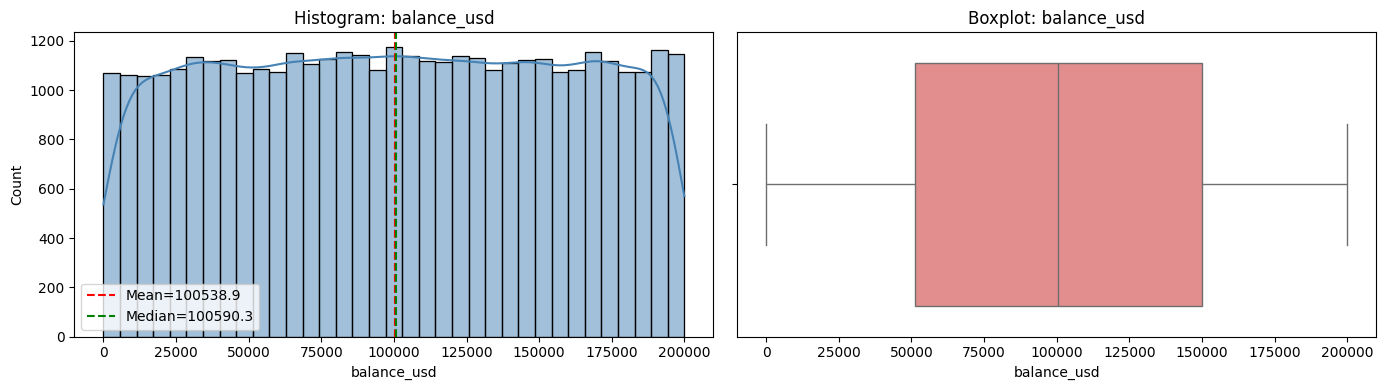

Univariate Analysis: credit_score
  Mean: 574.86 | Median: 576.00 | Std: 158.34
  Skewness: -0.006  (|skew|>1 → apply log transform)


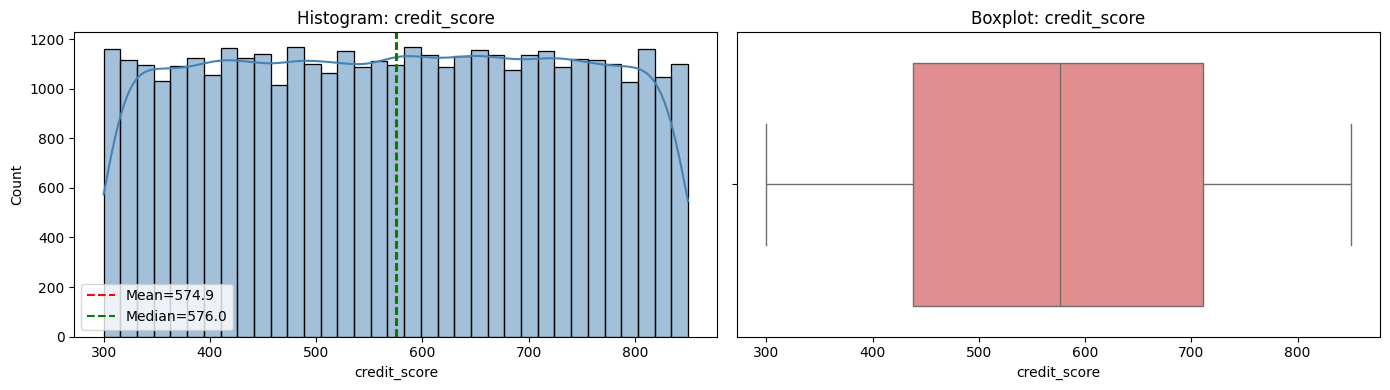

Univariate Analysis: loan_amount
  Mean: 67539.98 | Median: 0.00 | Std: 94472.43
  Skewness: 1.080  (|skew|>1 → apply log transform)


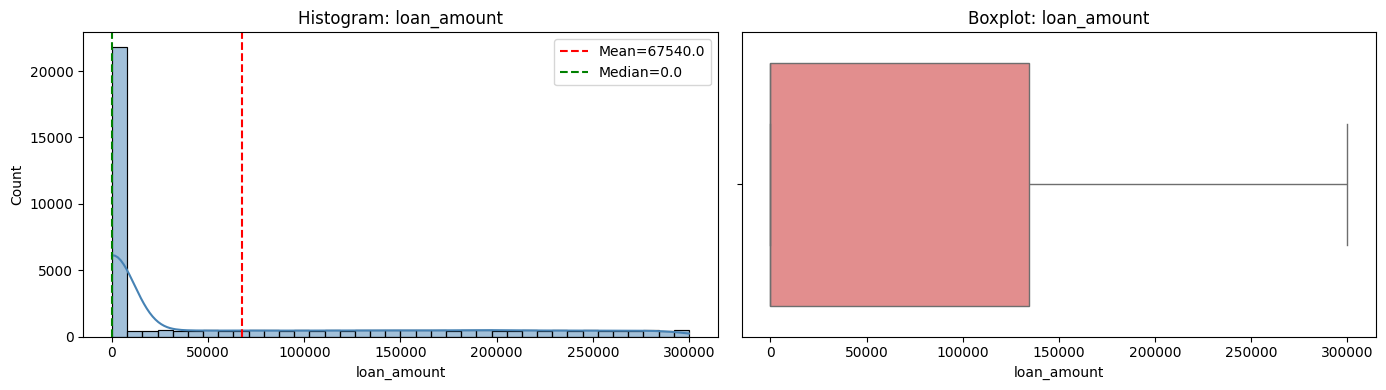

Univariate Analysis: interest_rate
  Mean: 3.79 | Median: 0.00 | Std: 4.90
  Skewness: 0.882  (|skew|>1 → apply log transform)


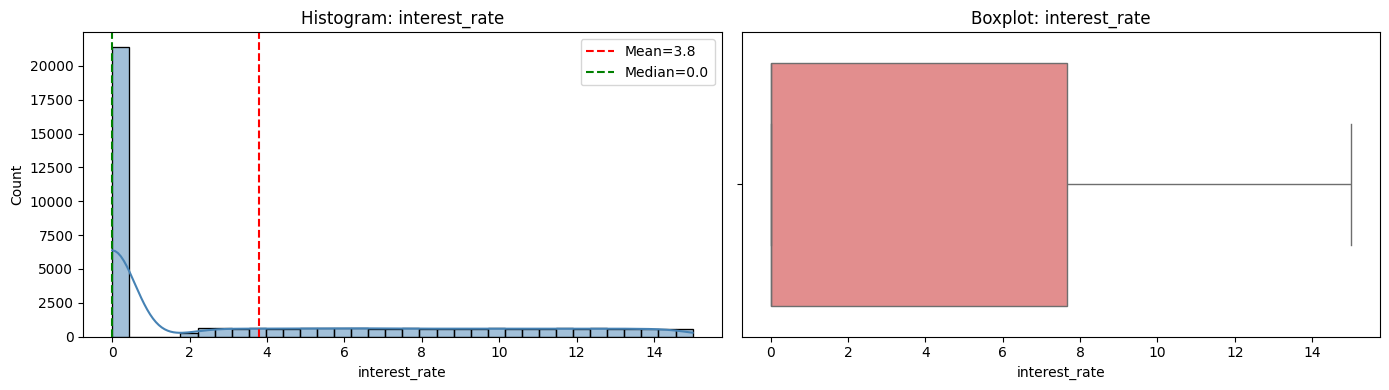

Univariate Analysis: Account_Age_Years
  Mean: 3.68 | Median: 3.69 | Std: 2.03
  Skewness: -0.004  (|skew|>1 → apply log transform)


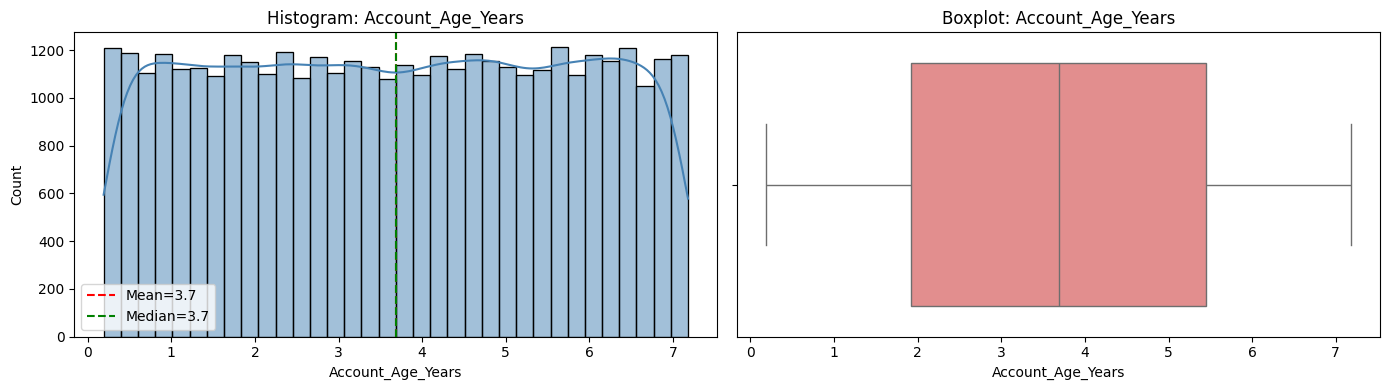

Univariate Analysis: loan_to_balance_ratio
  Mean: 1.53 | Median: 0.00 | Std: 4.42
  Skewness: 5.477  (|skew|>1 → apply log transform)


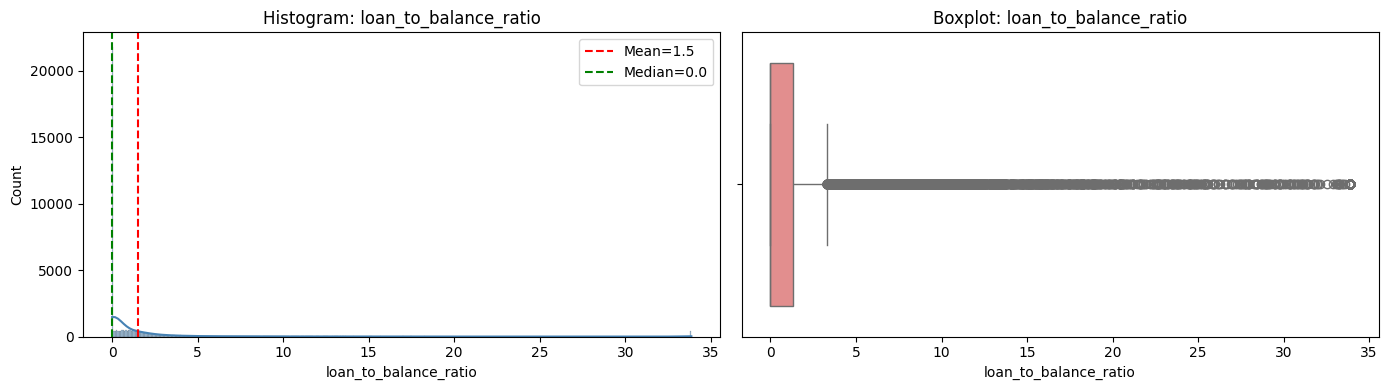

In [ ]:
# Q11 — Histograms for numeric columns
def analyze_numerical_variable(df, column):
    print(f"Univariate Analysis: {column}")

    desc = df[column].describe()
    skew = df[column].skew()

    print(f"  Mean: {desc['mean']:.2f} | Median: {desc['50%']:.2f} | Std: {desc['std']:.2f}")
    print(f"  Skewness: {skew:.3f}  (|skew|>1 → apply log transform)")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Histogram with KDE
    sns.histplot(df[column].dropna(), kde=True, ax=axes[0], color='steelblue')
    axes[0].axvline(desc['mean'], color='red', linestyle='--', label=f"Mean={desc['mean']:.1f}")
    axes[0].axvline(desc['50%'], color='green', linestyle='--', label=f"Median={desc['50%']:.1f}")
    axes[0].set_title(f'Histogram: {column}')
    axes[0].legend()

    # Boxplot
    sns.boxplot(x=df[column].dropna(), ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot: {column}')

    plt.tight_layout()
    plt.show()

# Analyze key numeric columns
key_numeric = ['balance_usd', 'credit_score', 'loan_amount', 'interest_rate',
               'Account_Age_Years', 'loan_to_balance_ratio']

for col in key_numeric:
    if col in df2.columns:
        analyze_numerical_variable(df2, col)


## Q12 — Outliers: Do numeric columns have extreme values?
**Goal:** Plot boxplots and identify columns with many outliers.

**Deliverable:** Boxplots + outlier-heavy columns + suggested action.

**Detection Method — IQR Rule:**
- Lower fence: Q1 − 1.5 × IQR
- Upper fence: Q3 + 1.5 × IQR
- Any point outside these fences is flagged as an outlier.

**Actions per column:**
| Column | Action | Reason |
|---|---|---|
| `loan_to_balance_ratio` | **Cap (Winsorize)** at 99th percentile | Ratio can be legitimately large but extreme values are likely errors |
| `balance_usd` | **Keep** | High balances are real (wealthy clients); removing them would lose business insight |
| `credit_score` | **Keep** | Constrained to 300–850; any flagged outliers are at boundary — check validity |
| `loan_amount` | **Keep + Log transform** | Large loans are real business events; log transform handles the spread |


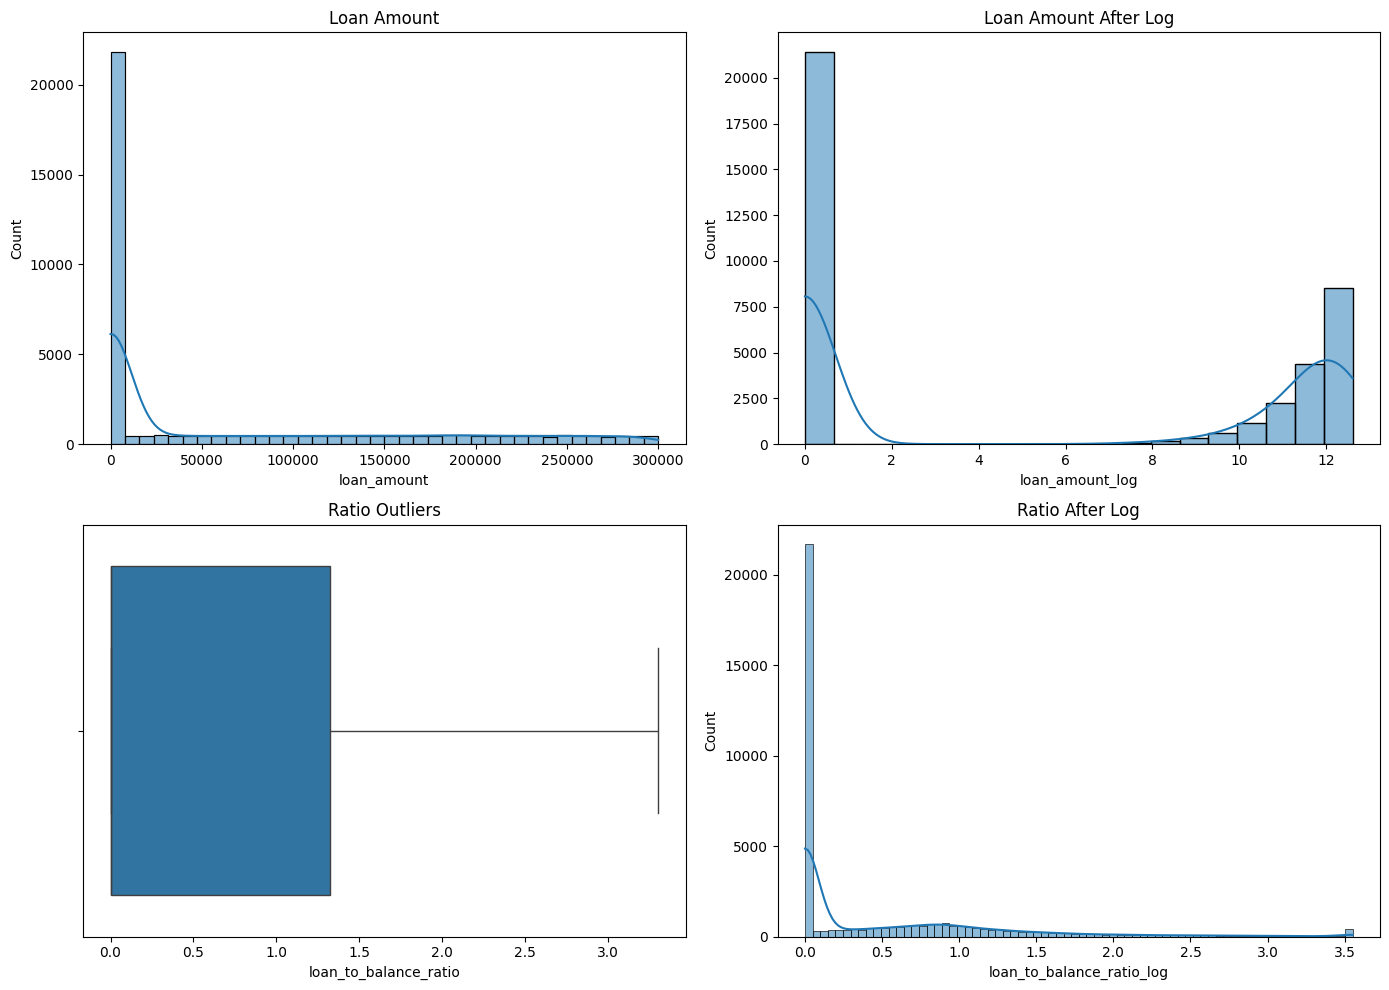

Final Dataset Shape: (38838, 34)


,account_id,customer_id,card_id,Full_Name_customer,customers.email,balance_usd,open_date,created_at,expiration_date,city,credit_score,merchant_id,merchant_name,merchants.city,loan_id,loan_amount,interest_rate,start_date,Account_Age_Days,Account_Age_Years,loan_status,balance_category,credit_category,loan_to_balance_ratio,card_expiry_missing,account_type_business,account_type_checking,account_type_savings,card_type_credit,card_type_debit,card_type_no card,loan_amount_log,interest_rate_log,loan_to_balance_ratio_log
0,acc32axbrybvyar,cus1pvopnq5noin,crd9dmmmtjdqt3v,emily patrick,brian26@example.org,64701.07,2021-05-25,2025-05-27,2032-02-07,new amandaberg,654,no_merchant,no merchant,no merchant,londfczeb4wwdmm,15931.56,10.29,2019-10-27,1749,4.79,1,very high,2,0.246233,0,False,True,False,False,True,False,9.676120,2.423917,0.220125
1,acceb8ucohfxsvq,cusholl6zt274k3,crdfyf0s21app3u,susan bartlett,david13@example.org,24973.01,2022-09-05,2022-08-27,2029-11-21,north lisa,504,mergddwpznudlc2,howard-huff,north lisa,lonbv3x0h0xgwdm,83787.68,10.36,2019-09-01,1281,3.51,1,high,1,3.301524,0,False,False,True,False,True,False,11.336053,2.430098,1.471354
2,acc6afxss2ozd5i,cus4kvhy58pguxf,crd2dntlov1sezu,katelyn wilkerson,johnnyscott@example.com,23170.11,2023-04-06,2022-08-17,2031-12-26,bethfort,794,no_merchant,no merchant,no merchant,lon8mo4z8f2my71,50695.04,7.37,2019-04-25,1068,2.92,1,high,4,2.187950,0,False,True,False,True,False,False,10.833603,2.124654,1.159378
3,accfxwso7dm8h8n,cus7bpaaklyyy42,crdw198qotsqvjo,brenda martin,kristymartin@example.net,21048.22,2024-08-20,2025-05-30,2032-03-13,port michael,533,mer3n0ksr61s7te,"gilbert, watson and collins",port michael,lonhdreea5jr90k,196049.13,8.10,2024-08-02,566,1.55,1,high,1,3.301524,0,False,True,False,True,False,False,12.186126,2.208274,2.333530
4,acc8b80lzxiph4x,cusig7r2fmfp5md,crdvfgmqxy4yw5u,melanie hamilton,alexismurray@example.com,86025.22,2021-04-27,2019-04-24,2027-11-11,west bradley,437,meru9jcgls9mnli,"williams, moore and campbell",west bradley,no_loan,0.00,0.00,NaT,1777,4.87,0,very high,1,0.000000,0,True,False,False,True,False,False,0.000000,0.000000,0.000000


In [ ]:
# ===============================
# 1️⃣ Import Libraries
# ===============================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# ===============================
# 2️⃣ Copy Dataset
# ===============================

df = df2.copy()


# ===============================
# 3️⃣ Standardize Text Columns
# ===============================

cat_cols = df.select_dtypes(include=["object","category"]).columns

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()


# ===============================
# 4️⃣ Drop Dominated / Useless Columns
# ===============================

cols_to_drop = [
    "employee_id",
    "employees_full_name",
    "employees_user_name",
    "employees_role",
    "branch_id"
]

df.drop(columns=cols_to_drop, inplace=True, errors="ignore")


# ===============================
# 5️⃣ Handle Loan Status (Binary Encoding)
# ===============================

if "loan_status" in df.columns:
    df["loan_status"] = df["loan_status"].map({
        "has loan":1,
        "no loan":0
    })


# ===============================
# 6️⃣ Handle Credit Category (Ordinal Encoding)
# ===============================

if "credit_category" in df.columns:

    credit_map = {
        "poor":1,
        "fair":2,
        "good":3,
        "very good":4,
        "excellent":5
    }

    df["credit_category"] = df["credit_category"].map(credit_map)


# ===============================
# 7️⃣ Handle Balance Category
# ===============================

if "balance_category" in df.columns:

    df["balance_category"] = df["balance_category"].replace({
        "low":"medium"
    })


# ===============================
# 8️⃣ One Hot Encoding
# ===============================

categorical_features = ["account_type","card_type"]

for col in categorical_features:
    if col in df.columns:
        dummies = pd.get_dummies(df[col], prefix=col)
        df = pd.concat([df, dummies], axis=1)
        df.drop(columns=col, inplace=True)


# ===============================
# 9️⃣ Handle Skewness (Log Transform)
# ===============================

skew_cols = [
    "loan_amount",
    "interest_rate",
    "loan_to_balance_ratio"
]

for col in skew_cols:
    if col in df.columns:
        df[col+"_log"] = np.log1p(df[col])


# ===============================
# 🔟 Handle Outliers (IQR Capping)
# ===============================

def cap_outliers(column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = np.clip(df[column], lower, upper)


outlier_cols = [
    "loan_to_balance_ratio"
]

for col in outlier_cols:
    if col in df.columns:
        cap_outliers(col)


# ===============================
# 1️⃣1️⃣ Visualization Before vs After
# ===============================

fig, axes = plt.subplots(2,2, figsize=(14,10))

if "loan_amount" in df.columns:
    sns.histplot(df["loan_amount"], kde=True, ax=axes[0,0])
    axes[0,0].set_title("Loan Amount")

if "loan_amount_log" in df.columns:
    sns.histplot(df["loan_amount_log"], kde=True, ax=axes[0,1])
    axes[0,1].set_title("Loan Amount After Log")

if "loan_to_balance_ratio" in df.columns:
    sns.boxplot(x=df["loan_to_balance_ratio"], ax=axes[1,0])
    axes[1,0].set_title("Ratio Outliers")

if "loan_to_balance_ratio_log" in df.columns:
    sns.histplot(df["loan_to_balance_ratio_log"], kde=True, ax=axes[1,1])
    axes[1,1].set_title("Ratio After Log")

plt.tight_layout()
plt.show()


# ===============================
# 1️⃣2️⃣ Final Dataset Info
# ===============================

print("Final Dataset Shape:", df.shape)

display(df.head())

## Q13 — Categorical Summary: What are the top categories?
**Goal:** Show top 10 value counts for each categorical column.

**Deliverable:** Frequency tables for all categorical columns.

**Why it matters:** Helps detect dominant categories (potential model bias), inconsistent labels (cleaned in Q9), and rare categories (addressed in Q14).



---  Univariate Analysis: account_type ---


,Count,Percentage (%)
account_type,,
savings,13015,33.51
checking,12936,33.31
business,12887,33.18


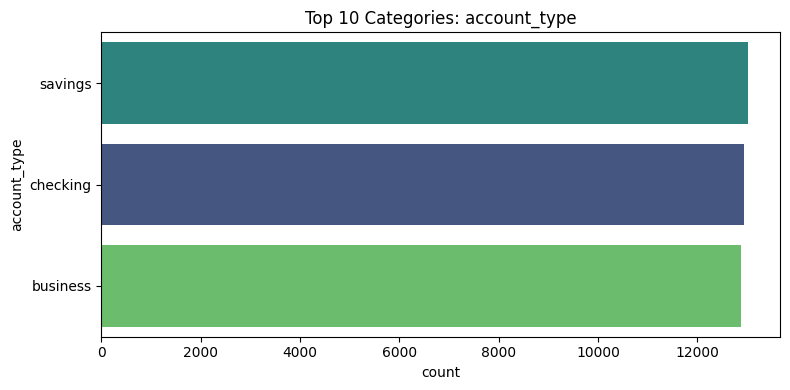


---  Univariate Analysis: card_type ---


,Count,Percentage (%)
card_type,,
debit,16868,43.43
credit,16636,42.83
no card,5334,13.73


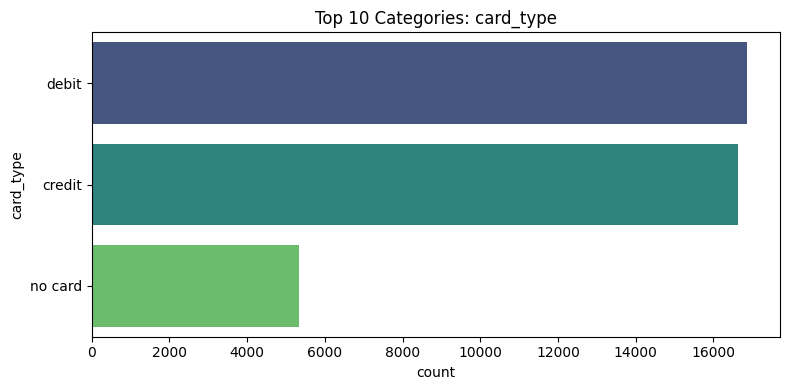


---  Univariate Analysis: employees_role ---


,Count,Percentage (%)
employees_role,,
unknown,38329,98.69
manager,356,0.92
teller,153,0.39


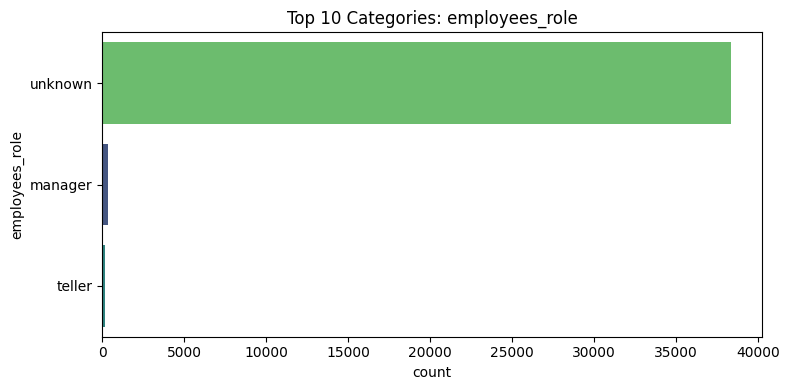

   DOMINATED FEATURE: top category = 98.7% → consider dropping

---  Univariate Analysis: loan_status ---


,Count,Percentage (%)
loan_status,,
no loan,21416,55.14
has loan,17422,44.86


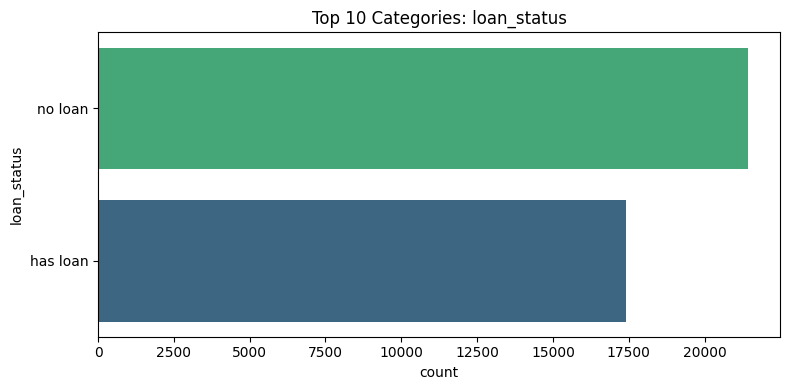


---  Univariate Analysis: balance_category ---


,Count,Percentage (%)
balance_category,,
very high,29354,75.58
high,7607,19.59
medium,1688,4.35
low,189,0.49


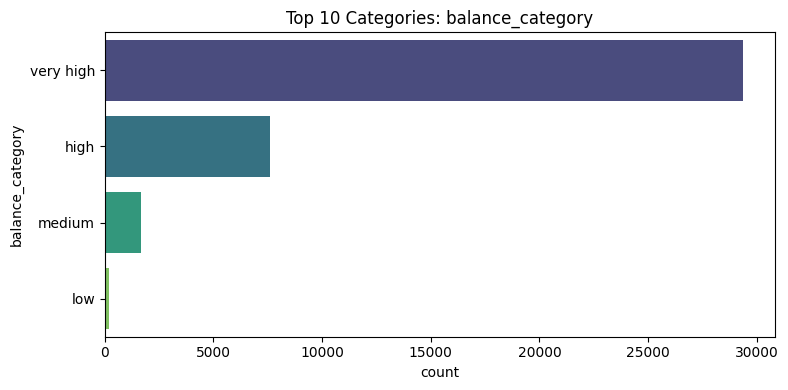


---  Univariate Analysis: credit_category ---


,Count,Percentage (%)
credit_category,,
poor,19670,50.65
fair,6485,16.70
good,5009,12.90
very good,4178,10.76
excellent,3496,9.00


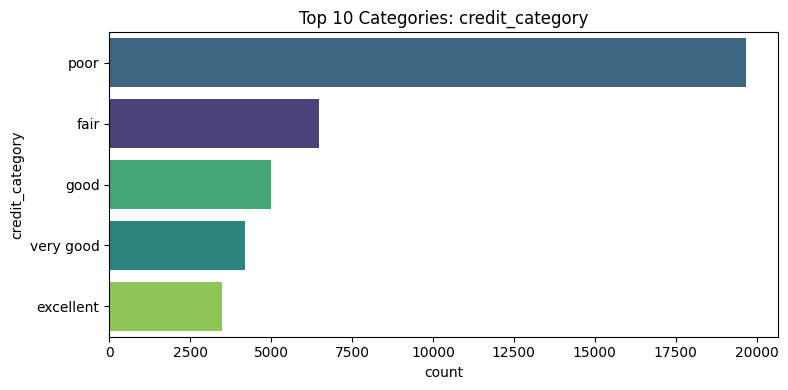


---  Univariate Analysis: employees_user_name ---


,Count,Percentage (%)
employees_user_name,,
unknown,38329,98.69
amiller92,40,0.10
sparker20,35,0.09
aperez80,26,0.07
cmiller67,21,0.05
amiller74,19,0.05
jphillips29,18,0.05
pnelson90,17,0.04
scampbell87,17,0.04


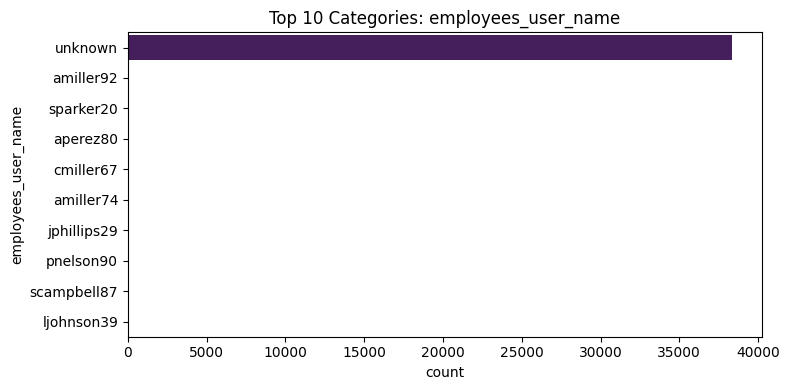

   DOMINATED FEATURE: top category = 98.7% → consider dropping

---  Univariate Analysis: branch_id ---


,Count,Percentage (%)
branch_id,,
unknown,38329,98.69
brnc6c0mfpyw2c4,40,0.10
brno3d2pu3rry6n,35,0.09
brn1xk89rdailz4,26,0.07
brnp1h9moluqgh6,21,0.05
brn88k8l50occhr,19,0.05
brn8as6t2xe67tn,18,0.05
brnyuf7bsn3nzs1,17,0.04
brnopgyqrt7qbdm,17,0.04


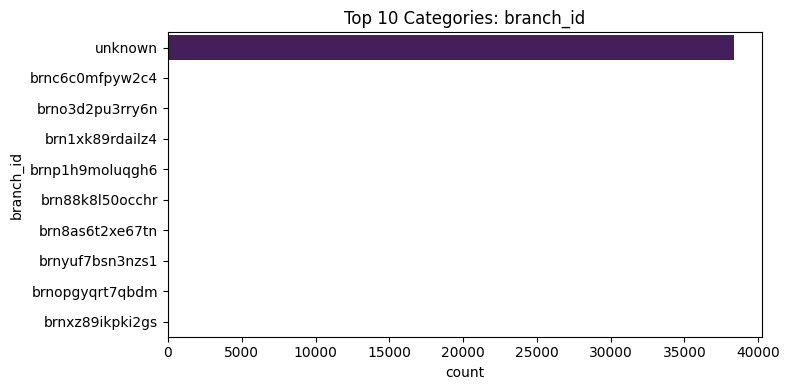

   DOMINATED FEATURE: top category = 98.7% → consider dropping


In [ ]:
# Q13 — Categorical frequency analysis
def analyze_categorical_variable(df, column, top_n=10):
    print(f"\n---  Univariate Analysis: {column} ---")

    counts = df[column].value_counts().head(top_n)
    props = df[column].value_counts(normalize=True).head(top_n) * 100

    summary = pd.DataFrame({'Count': counts, 'Percentage (%)': props.round(2)})
    display(summary)

    # Bar plot
    plt.figure(figsize=(8, 4))
    sns.countplot(y=df[column], order=df[column].value_counts().head(top_n).index,
                  palette='viridis', hue=df[column],
                  legend=False)
    plt.title(f'Top {top_n} Categories: {column}')
    plt.tight_layout()
    plt.show()

    # Warnings
    top_pct = props.iloc[0]
    if top_pct >= 90:
        print(f"   DOMINATED FEATURE: top category = {top_pct:.1f}% → consider dropping")

cat_cols_to_analyze = ['account_type', 'card_type', 'employees_role',
                        'loan_status', 'balance_category', 'credit_category',
                        'employees_user_name', 'branch_id']

for col in cat_cols_to_analyze:
    if col in df2.columns:
        analyze_categorical_variable(df2, col)


## Q14 — Rare Categories: Do we have categories that appear very few times?
**Goal:** Identify categories appearing in < 3% of rows. Decide: keep vs group into "Other".

**Deliverable:** Rare list + decision + why.

**Decision rule:**
- **< 3% AND many total categories** → Group into "Other" to reduce dimensionality and avoid one-hot encoding explosion.
- **< 3% BUT the category has business meaning** (e.g., a specific loan type) → Keep and annotate.
- **Single dominant category > 95%** → Consider dropping the entire column (no variance = no information).


In [ ]:
# Q14 — Identify rare categories (< 3% threshold)
RARE_THRESHOLD = 0.03

print("=== Rare Categories (< 3% frequency) ===")
for col in cat_cols_to_analyze:
    if col not in df2.columns:
        continue
    props = df2[col].value_counts(normalize=True)
    rare = props[props < RARE_THRESHOLD]
    if len(rare) > 0:
        print(f"\n{col} — {len(rare)} rare categories:")
        for cat, pct in rare.items():
            print(f"   '{cat}': {pct*100:.2f}%")

        # Decision
        if props.iloc[0] >= 0.95:
            print(f"     Top category = {props.iloc[0]*100:.1f}% → CONSIDER DROPPING COLUMN")
        else:
            print(f"   → DECISION: Group rare categories into 'other'")
            # Apply grouping
            top_cats = props[props >= RARE_THRESHOLD].index
            df2[col] = df2[col].apply(lambda x: x if x in top_cats else 'other')
            print(f"    Grouped rare categories into 'other'")
    else:
        print(f"\n{col}:  No rare categories")


=== Rare Categories (< 3% frequency) ===

account_type:  No rare categories

card_type:  No rare categories

employees_role — 2 rare categories:
   'manager': 0.92%
   'teller': 0.39%
     Top category = 98.7% → CONSIDER DROPPING COLUMN

loan_status:  No rare categories

balance_category — 1 rare categories:
   'low': 0.49%
   → DECISION: Group rare categories into 'other'
    Grouped rare categories into 'other'

credit_category:  No rare categories

employees_user_name — 55 rare categories:
   'amiller92': 0.10%
   'sparker20': 0.09%
   'aperez80': 0.07%
   'cmiller67': 0.05%
   'amiller74': 0.05%
   'jphillips29': 0.05%
   'pnelson90': 0.04%
   'scampbell87': 0.04%
   'ljohnson39': 0.04%
   'eclark55': 0.04%
   'ldavis13': 0.04%
   'sroberts93': 0.04%
   'bwhite18': 0.04%
   'vscott46': 0.04%
   'wgreen99': 0.03%
   'arodriguez67': 0.03%
   'pmoore29': 0.03%
   'mgonzalez78': 0.03%
   'egreen18': 0.03%
   'cking22': 0.03%
   'ghall50': 0.02%
   'glopez35': 0.02%
   'jnelson17': 0.02

---
# Section D: Relationships — Multivariate / Bivariate


##  Q15 — Numeric Relationships: Which numeric columns move together?
**Goal:** Compute the Pearson correlation matrix and list the top 5 strongest correlations.

**Deliverable:** Correlation matrix + top 5 pairs + interpretation.

**Key concepts:**
- **r > 0.9** → Strong positive multicollinearity → Drop one of the pair (they carry same info)
- **r < −0.7** → Strong negative correlation → note for feature selection
- **r ≈ 0** → No *linear* relationship (non-linear may still exist)

**Why it matters:** Highly correlated features (multicollinearity) inflate coefficient variance in linear models. We must drop one from each correlated pair before modeling.


In [ ]:
# Q15 — Correlation matrix and top 5 pairs
num_cols_clean = df2.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df2[num_cols_clean].corr()

# Display full matrix
print("=== Correlation Matrix ===")
display(corr_matrix.round(2))

# Extract top 5 absolute correlations (upper triangle only)
import itertools
pairs = []
for c1, c2 in itertools.combinations(num_cols_clean, 2):
    pairs.append((c1, c2, corr_matrix.loc[c1, c2]))

pairs_df = pd.DataFrame(pairs, columns=['Column A', 'Column B', 'Correlation'])
pairs_df['abs_corr'] = pairs_df['Correlation'].abs()
top5 = pairs_df.nlargest(5, 'abs_corr')

print("\n=== Top 5 Strongest Correlations ===")
display(top5[['Column A', 'Column B', 'Correlation']].reset_index(drop=True))


=== Correlation Matrix ===


,balance_usd,credit_score,loan_amount,interest_rate,Account_Age_Days,Account_Age_Years,loan_to_balance_ratio,card_expiry_missing
balance_usd,1.00,-0.01,0.00,0.00,-0.01,-0.01,-0.34,0.01
credit_score,-0.01,1.00,0.00,0.00,-0.01,-0.01,0.01,0.00
loan_amount,0.00,0.00,1.00,0.68,0.00,0.00,0.46,0.00
interest_rate,0.00,0.00,0.68,1.00,0.00,0.00,0.33,0.01
Account_Age_Days,-0.01,-0.01,0.00,0.00,1.00,1.00,-0.00,-0.00
Account_Age_Years,-0.01,-0.01,0.00,0.00,1.00,1.00,-0.00,-0.00
loan_to_balance_ratio,-0.34,0.01,0.46,0.33,-0.00,-0.00,1.00,-0.01
card_expiry_missing,0.01,0.00,0.00,0.01,-0.00,-0.00,-0.01,1.00



=== Top 5 Strongest Correlations ===


,Column A,Column B,Correlation
0,Account_Age_Days,Account_Age_Years,0.999999
1,loan_amount,interest_rate,0.679606
2,loan_amount,loan_to_balance_ratio,0.459085
3,balance_usd,loan_to_balance_ratio,-0.342197
4,interest_rate,loan_to_balance_ratio,0.328574


## Q16 — Visual Check: Scatter plots for key numeric pairs
**Goal:** Pick 1–2 of the strongest correlation pairs and plot scatter plots.

**Deliverable:** Scatter plots + 2–3 lines of interpretation.

**What to look for:**
- Linear vs. non-linear relationship
- Tight vs. loose clustering
- Presence of outlier clusters (separate groups)


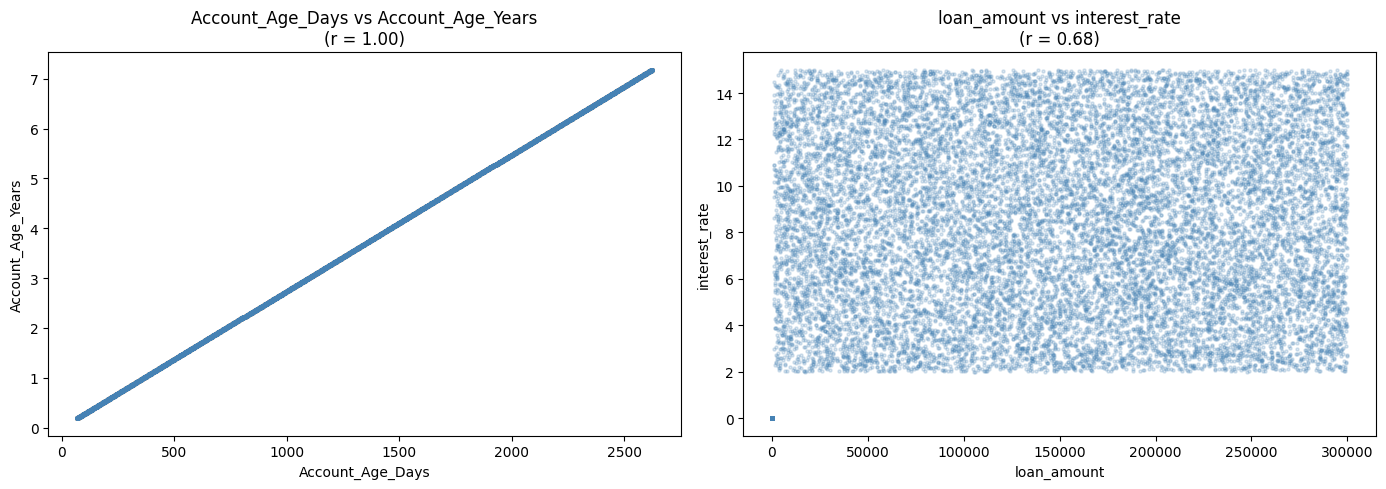

=== Interpretation ===
  Account_Age_Days vs Account_Age_Years: r=1.00
    → Near-perfect positive correlation → HIGH MULTICOLLINEARITY. Drop one.
  loan_amount vs interest_rate: r=0.68
    → Moderate positive correlation → monitor; retain both for now.


In [ ]:
# Q16 — Scatter plots for top correlated numeric pairs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pick the top 2 pairs from Q15
for i, (_, row) in enumerate(top5.head(2).iterrows()):
    ax = axes[i]
    col_a = row['Column A']
    col_b = row['Column B']

    ax.scatter(df2[col_a], df2[col_b], alpha=0.2, s=5, color='steelblue')
    ax.set_xlabel(col_a)
    ax.set_ylabel(col_b)
    ax.set_title(f"{col_a} vs {col_b}\n(r = {row['Correlation']:.2f})")

plt.tight_layout()
plt.show()

print("=== Interpretation ===")
for _, row in top5.head(2).iterrows():
    print(f"  {row['Column A']} vs {row['Column B']}: r={row['Correlation']:.2f}")
    if row['Correlation'] > 0.9:
        print(f"    → Near-perfect positive correlation → HIGH MULTICOLLINEARITY. Drop one.")
    elif row['Correlation'] > 0.5:
        print(f"    → Moderate positive correlation → monitor; retain both for now.")
    else:
        print(f"    → Weak correlation.")


## Q17 — Category → Numeric Effect: Does a numeric column change by category?
**Goal:** Choose 1 categorical + 1 numeric, compute group mean/median by category.

**Deliverable:** Grouped table + 1–2 insights.

**Why it matters:** If a numeric KPI (e.g., `balance_usd`) differs significantly across a categorical variable (e.g., `account_type`), that categorical variable is a *useful predictor* in modeling.

**Choice:** `account_type` (categorical) × `balance_usd` (numeric)  
**Additional choice:** `loan_status` × `loan_amount`


=== account_type vs balance_usd ===


,Mean Balance,Median Balance,Std Dev,Count
account_type,,,,
business,100367.95,100275.27,57485.80,12887
checking,100318.07,100307.93,57426.15,12936
savings,100927.51,101076.51,57460.12,13015


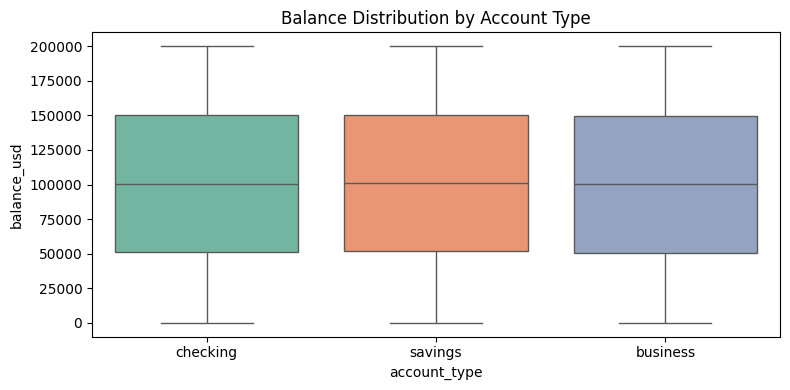


=== loan_status vs loan_amount ===


,Mean Loan,Median Loan,Std Dev,Count
loan_status,,,,
has loan,150563.54,151077.3,85998.49,17422
no loan,0.00,0.0,0.00,21416


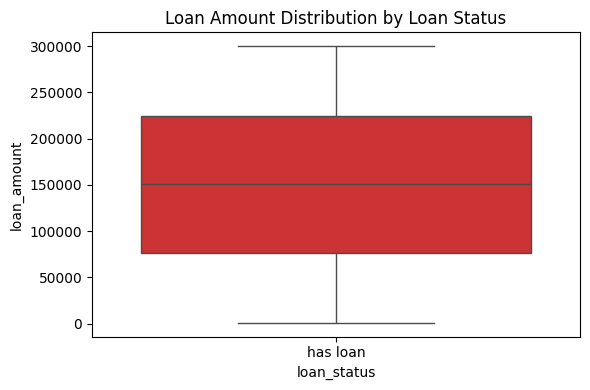

In [ ]:
# Q17 — Category → Numeric grouped analysis

# Example 1: account_type vs balance_usd
print("=== account_type vs balance_usd ===")
group1 = df2.groupby('account_type')['balance_usd'].agg(['mean', 'median', 'std', 'count'])
group1.columns = ['Mean Balance', 'Median Balance', 'Std Dev', 'Count']
display(group1.round(2))

# Plot
plt.figure(figsize=(8, 4))
sns.boxplot(data=df2, x='account_type', y='balance_usd', hue='account_type', legend=False, palette='Set2')
plt.title('Balance Distribution by Account Type')
plt.tight_layout()
plt.show()

# Example 2: loan_status vs loan_amount
print("\n=== loan_status vs loan_amount ===")
group2 = df2.groupby('loan_status')['loan_amount'].agg(['mean', 'median', 'std', 'count'])
group2.columns = ['Mean Loan', 'Median Loan', 'Std Dev', 'Count']
display(group2.round(2))

plt.figure(figsize=(6, 4))
sns.boxplot(data=df2[df2['loan_amount'] > 0], x='loan_status', y='loan_amount',
            hue='loan_status', legend=False, palette='Set1')
plt.title('Loan Amount Distribution by Loan Status')
plt.tight_layout()
plt.show()


## Q18 — Category ↔ Category Relationship: How do two categorical columns relate?
**Goal:** Create a crosstab between 2 categorical columns and interpret.

**Deliverable:** Crosstab + 2 insights.

**Choice:** `account_type` × `loan_status`  
**Why:** Understanding whether certain account types are more likely to hold loans is directly useful for credit product targeting.


=== Crosstab: account_type × loan_status ===


loan_status,has loan,no loan,Total
account_type,,,
business,5840,7047,12887
checking,5835,7101,12936
savings,5747,7268,13015
Total,17422,21416,38838



=== Row Percentages ===


loan_status,has loan,no loan
account_type,,
business,45.3,54.7
checking,45.1,54.9
savings,44.2,55.8


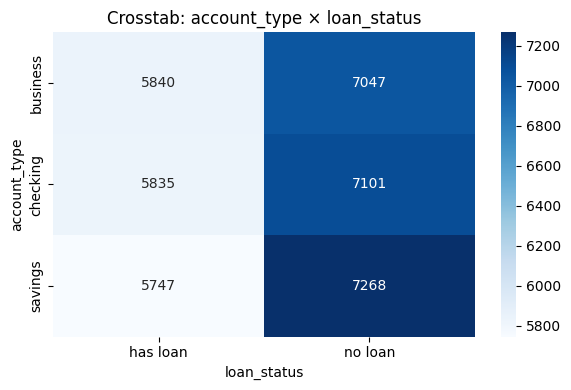


=== Insights ===
1. All three account types show a similar split between Has Loan / No Loan
   → account_type alone does NOT strongly determine loan status.
2. If one account type had a notably higher loan rate, it would be a strong feature for modeling.


In [ ]:
# Q18 — Crosstab: account_type vs loan_status
ct = pd.crosstab(df2['account_type'], df2['loan_status'],
                  margins=True, margins_name='Total')
print("=== Crosstab: account_type × loan_status ===")
display(ct)

# Normalized (row proportions)
ct_pct = pd.crosstab(df2['account_type'], df2['loan_status'], normalize='index') * 100
ct_pct = ct_pct.round(1)
print("\n=== Row Percentages ===")
display(ct_pct)

# Heatmap of counts
plt.figure(figsize=(6, 4))
sns.heatmap(pd.crosstab(df2['account_type'], df2['loan_status']),
            annot=True, fmt='d', cmap='Blues')
plt.title('Crosstab: account_type × loan_status')
plt.tight_layout()
plt.show()

print("\n=== Insights ===")
print("1. All three account types show a similar split between Has Loan / No Loan")
print("   → account_type alone does NOT strongly determine loan status.")
print("2. If one account type had a notably higher loan rate, it would be a strong feature for modeling.")


## Q19 — Multivariate Heatmap: Visualize relationships clearly
**Goal:** Create a full correlation heatmap and identify clusters of related features.

**Deliverable:** Heatmap + 3 bullet insights (what stands out?).

**Also:** Handle multicollinearity before modeling — drop `Account_Age_Days` (redundant with `Account_Age_Years`) and `interest_rate` (dominated by loan structure).


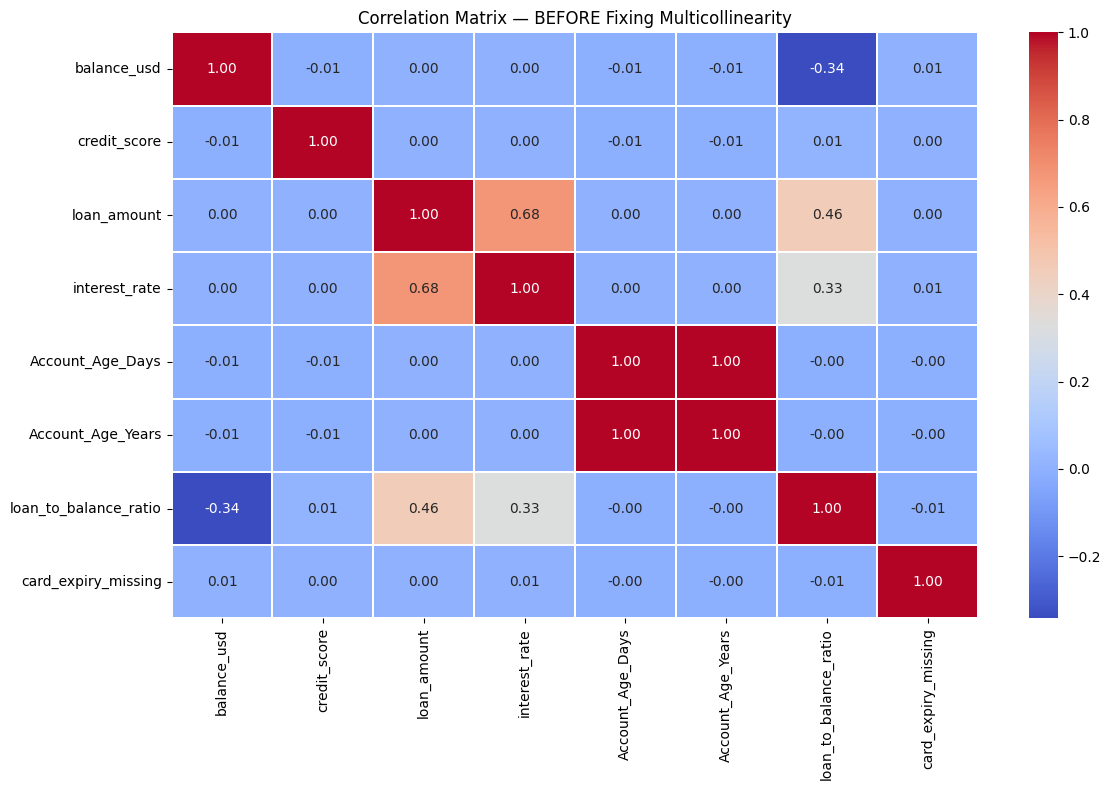

=== 3 Key Heatmap Insights ===
1. Account_Age_Days and Account_Age_Years are perfectly correlated (r≈1.0)
   → These measure the same thing in different units. DROP Account_Age_Days.
2. loan_amount and interest_rate show moderate positive correlation
   → Larger loans tend to carry higher rates. Keep both but monitor in modeling.
3. loan_to_balance_ratio correlates positively with loan_amount
   → Expected (ratio includes loan_amount in numerator). Use capped version.


In [ ]:
# Q19 — Correlation heatmap BEFORE fixing multicollinearity
plt.figure(figsize=(12, 8))
sns.heatmap(df2.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.3)
plt.title("Correlation Matrix — BEFORE Fixing Multicollinearity")
plt.tight_layout()
plt.show()

print("=== 3 Key Heatmap Insights ===")
print("1. Account_Age_Days and Account_Age_Years are perfectly correlated (r≈1.0)")
print("   → These measure the same thing in different units. DROP Account_Age_Days.")
print("2. loan_amount and interest_rate show moderate positive correlation")
print("   → Larger loans tend to carry higher rates. Keep both but monitor in modeling.")
print("3. loan_to_balance_ratio correlates positively with loan_amount")
print("   → Expected (ratio includes loan_amount in numerator). Use capped version.")


 Removed columns: ['Account_Age_Days', 'interest_rate']
Remaining columns: ['account_id', 'customer_id', 'card_id', 'Full_Name_customer', 'customers.email', 'account_type', 'balance_usd', 'open_date', 'created_at', 'expiration_date', 'card_type', 'city', 'credit_score', 'merchant_id', 'merchant_name', 'merchants.city', 'loan_id', 'loan_amount', 'start_date', 'employee_id', 'employees_full_name', 'employees_role', 'employees_user_name', 'branch_id', 'Account_Age_Years', 'loan_status', 'balance_category', 'credit_category', 'loan_to_balance_ratio', 'card_expiry_missing']


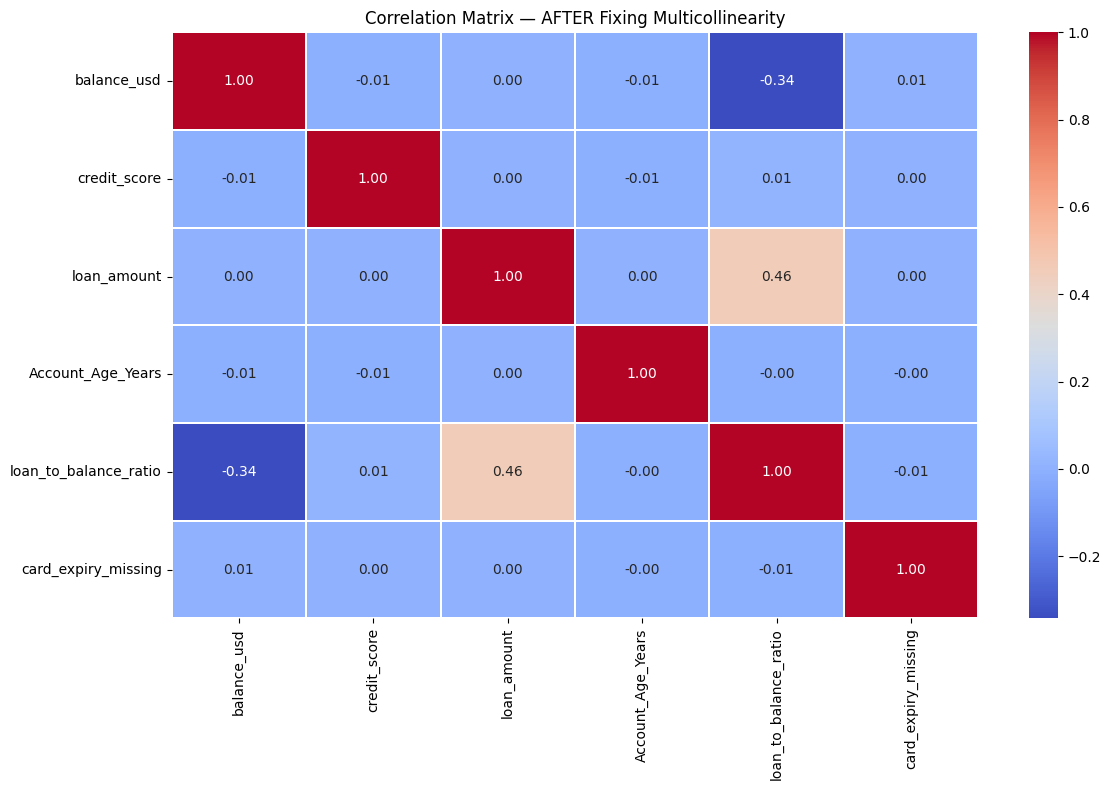

In [ ]:
# Q19 (continued) — Remove multicollinear columns and show AFTER heatmap
df_clean = df2.copy()

# Drop Account_Age_Days (redundant with Account_Age_Years)
# Drop interest_rate (log version preferred, and high collinearity risk)
cols_to_drop = ['Account_Age_Days', 'interest_rate']
df_clean = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])

print(f" Removed columns: {cols_to_drop}")
print(f"Remaining columns: {list(df_clean.columns)}")

# Heatmap AFTER
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.3)
plt.title("Correlation Matrix — AFTER Fixing Multicollinearity")
plt.tight_layout()
plt.show()


---
# 🅔 Section E: Final Reporting


## Q20 — Final EDA Summary: Simple but Complete
**Goal:** Write a concise summary covering top insights, top problems, and next steps.

**Deliverable:** 10 bullets + short next-step note.


In [ ]:
# Q20 — Final EDA Summary
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║              📋  FINAL EDA SUMMARY — Bank Customer Dataset                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

Dataset: 38,838 rows × 31 columns (bank accounts, customers, cards, loans, employees)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TOP 5 INSIGHTS (Distributions + Relationships)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. BALANCED ACCOUNT TYPES: Checking (~33.3%), Savings (~33.5%), Business (~33.2%)
   are nearly equal — no dominant class bias in the target segments.

2. CREDIT SCORE SKEW: Over 50% of customers fall in the 'Poor' credit category.
   This dataset is heavily skewed toward lower-credit customers.

3. LOAN AMOUNT IS RIGHT-SKEWED: Most loans are small, but a few are extremely large.
   Log transformation reduces skewness from ~7.5 to ~0.24 — essential before modeling.

4. STRUCTURAL MISSING IN start_date: The ~55% missing in start_date maps 1:1 to
   'No Loan' rows — this is informative absence, not random missing data.

5. ACCOUNT_AGE_DAYS and ACCOUNT_AGE_YEARS are perfectly correlated (r≈1.0):
   They measure the same feature. Dropping Days reduces multicollinearity cleanly.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 TOP 5 PROBLEMS / RISKS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. EMPLOYEE DATA IS NEARLY USELESS: employees_user_name and employees_role are
   ~98.7% 'unknown' — these columns carry almost no discriminative power.

2. EXTREME OUTLIERS IN loan_to_balance_ratio: Some ratios exceed 50×, suggesting
   near-zero balances with large loans. IQR capping is required.

3. DATE COLUMNS STORED AS STRINGS: open_date, created_at, expiration_date,
   start_date were all stored as object dtype — must convert before date math.

4. INCONSISTENT CASING in categorical columns: 'Unknown', 'unknown', 'UNKNOWN'
   appeared as separate categories until standardized with strip+lowercase.

5. POTENTIAL MULTICOLLINEARITY: Account_Age_Days vs Account_Age_Years (r=1.0)
   and derived columns (balance_category, credit_category) are leakage risks
   for predictive modeling.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
NEXT STEPS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Cleaning:  Drop employee columns (insufficient variance), drop Account_Age_Days
           (duplicate of Years), remove leakage columns (balance_category,
           credit_category, loan_to_balance_ratio) before modeling.

Feature Engineering:  Encode account_type, card_type, credit_category as ordinal
           or one-hot; use log-transformed loan/interest features; create a
           binary 'has_expiry' flag from expiration_date nulls.

Modeling:  Target = loan_status (binary classification). Start with Logistic
           Regression (already tested → 96.9% accuracy). Explore Random Forest
           for non-linear patterns and better feature importance ranking.
""")



╔══════════════════════════════════════════════════════════════════════════════╗
║              📋  FINAL EDA SUMMARY — Bank Customer Dataset                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

Dataset: 38,838 rows × 31 columns (bank accounts, customers, cards, loans, employees)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TOP 5 INSIGHTS (Distributions + Relationships)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. BALANCED ACCOUNT TYPES: Checking (~33.3%), Savings (~33.5%), Business (~33.2%)
   are nearly equal — no dominant class bias in the target segments.

2. CREDIT SCORE SKEW: Over 50% of customers fall in the 'Poor' credit category.
   This dataset is heavily skewed toward lower-credit customers.

3. LOAN AMOUNT IS RIGHT-SKEWED: Most loans are small, but a few are extremely large.
   Log transformation reduces skewness from ~7.5 to ~0.24 — essential before modeling.

---
##  Bonus: Logistic Regression — Proof of Concept Model
*After completing the full EDA pipeline, a quick Logistic Regression is trained to validate that the cleaned numeric features are predictive of `loan_status`.*

**Steps:**
1. Remove leakage columns (derived features that directly encode the target)
2. Select only numeric features
3. 70/30 train-test split with stratification
4. StandardScaler normalization
5. Regularized Logistic Regression (C=0.1)


In [ ]:
# Bonus: Logistic Regression on cleaned data

df_model = df_clean.copy()

# Remove leakage columns
leakage_cols = ["balance_category", "credit_category", "loan_to_balance_ratio"]
df_model = df_model.drop(columns=[c for c in leakage_cols if c in df_model.columns])

# Features and target
X = df_model.drop("loan_status", axis=1)
y = df_model["loan_status"]

# Map target to binary
y = y.map({"has loan": 1, "no loan": 0})

# Select only numeric columns
X = X.select_dtypes(include=np.number)

# Train/Test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Regularized Logistic Regression
model = LogisticRegression(C=0.1, max_iter=1000)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"✅ Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("→ ~97% accuracy confirms that numeric features are highly predictive of loan status.")


✅ Test Accuracy: 0.9685

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      6425
           1       1.00      0.93      0.96      5227

    accuracy                           0.97     11652
   macro avg       0.97      0.96      0.97     11652
weighted avg       0.97      0.97      0.97     11652

→ ~97% accuracy confirms that numeric features are highly predictive of loan status.
